<a href="https://colab.research.google.com/github/JoelHuitron/INTELIGENCIA-ARTIFICIAL/blob/JoelHuitron-patch-6/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad 8: Redes Neuronales Convolucionales**




# UANL FIME
# Inteligencia Artificial y Redes Neuronales



Instrucciones.-

* El estudiante entrenará un modelo de Red Neuronal Convolucional en Google Colab por medio del lenguaje de programación Python. Este modelo usará el conjunto de datos MNIST; este conjunto de datos contiene imágenes de baja resolución con dígitos del 0 al 9 escritos a mano. El conjunto de datos es parte de la librería Keras. Más información acerca de este conjunto de datos: https://keras.io/api/datasets/mnist/  

* Durante el preprocesamiento de los datos, se utilizará la función “load_data()” de la librería Keras para cargar el conjunto de datos y generar los conjuntos de entrenamiento (train_data, train_labels) y de prueba (test_data, test_label). Se puede utilizar la división de datos predeterminada por esta misma función.

* Se entrenará una red neuronal artificial prealimentada con los datos de entrenamiento utilizando la función “fit” de la librería tensorflow. El estudiante propondrá una estructura de red neuronal artificial prealimentada. La función de activación en la capa de salida deberá ser softmax.

* Se establecerá el tipo de función de pérdida y optimizador a utilizar. La métrica a utilizar para evaluar el proceso de entrenamiento será la exactitud (accuracy).

* Utilizar la función “evaluate” para mostrar la exactitud de predicción del modelo con el conjunto de datos de prueba (test_data).

* Realizar 5 diferentes predicciones con el conjunto de datos de prueba (test_data). En el resultado mostrar la predicción y el valor real.

* Responde las siguientes preguntas:

* ¿Cuántas épocas usaste para mejorar el rendimiento del modelo en comparación con la red neuronal prealimentada de la actividad 5?

* ¿Obtuviste un mejor rendimiento con este modelo o con el de la actividad 5? * * ¿Por qué?

1. Importamos librerias

In [ ]:
# importar librerías
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np
from tensorflow.keras.layers import Conv2D, MaxPooling2D

2. Cargar el conjunto de datos MNIST

In [ ]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


3. Preprocesamiento de datos

In [ ]:
# Normalizar las imágenes
train_data = train_data / 255.0
test_data = test_data / 255.0

# Ajustar dimensiones para CNN
train_data = train_data.reshape(-1, 28, 28, 1)
test_data = test_data.reshape(-1, 28, 28, 1)

**4. Definir, compilr, entrer y evaluar el modelo**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.8787 - loss: 0.3860 - val_accuracy: 0.9779 - val_loss: 0.0780
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9814 - loss: 0.0554 - val_accuracy: 0.9881 - val_loss: 0.0427
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9900 - loss: 0.0332 - val_accuracy: 0.9859 - val_loss: 0.0498
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.9923 - loss: 0.0236 - val_accuracy: 0.9861 - val_loss: 0.0465
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9932 - loss: 0.0193 - val_accuracy: 0.9893 - val_loss: 0.0408
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9962 - loss: 0.0113 - val_accuracy: 0.9893 - val_loss: 0.0400
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9960 - loss: 0.0117 - val_accuracy: 0.9904 - val_loss: 0.0372
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.9976 -

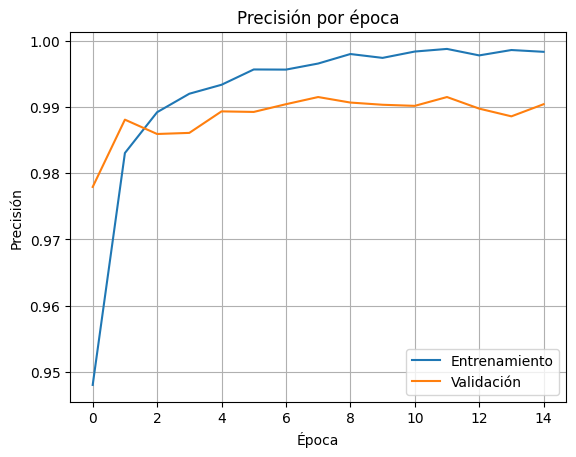

In [ ]:
train_labels_cat = to_categorical(train_labels, num_classes=10)
test_labels_cat = to_categorical(test_labels, num_classes=10)

modelo = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # Capa de salida con softmax para 10 clases
])

modelo.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history = modelo.fit(train_data, train_labels_cat,
                     epochs=15,
                     validation_split=0.2,
                     batch_size=32)

test_loss, test_accuracy = modelo.evaluate(test_data, test_labels_cat)
print(f"Exactitud en el conjunto de prueba: {test_accuracy:.4f}")

modelo.save("modelo_mnist_cnn.keras")

# 10. Graficar precisión
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Precisión por época')
plt.legend()
plt.grid()
plt.show()


**5. Predicciones**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

 Imagen #1
 Valor real: 7
 Predicción : 7


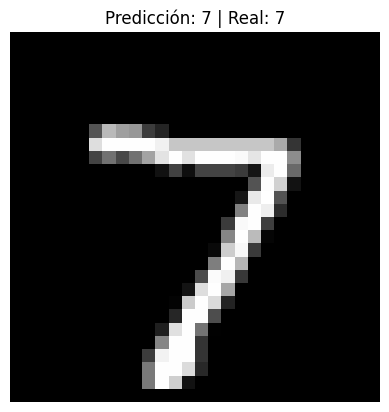

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

 Imagen #2
 Valor real: 2
 Predicción : 2


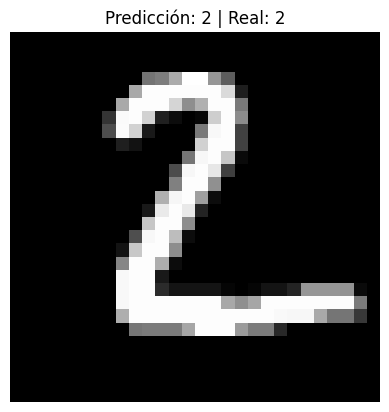

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

 Imagen #3
 Valor real: 1
 Predicción : 1


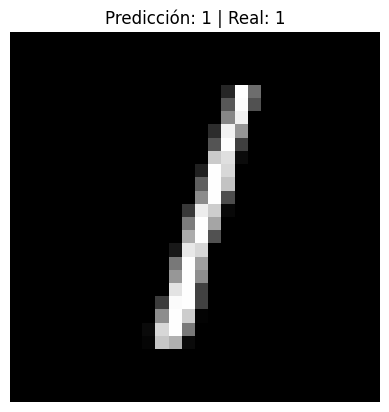

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

 Imagen #4
 Valor real: 0
 Predicción : 0


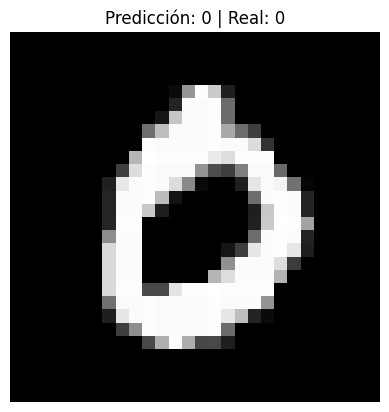

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

 Imagen #5
 Valor real: 4
 Predicción : 4


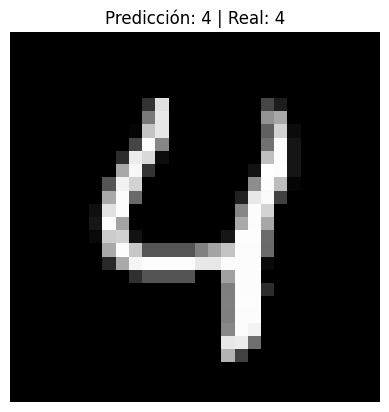

In [ ]:
# Cargar modelo .keras
modelo = tf.keras.models.load_model("modelo_mnist_cnn.keras")

# Cargar datos de prueba
(_, _), (test_data, test_labels) = mnist.load_data()

# Normalizar
test_data = test_data / 255.0

# Expandir dimensiones para incluir canal (28, 28) → (28, 28, 1)
test_data = np.expand_dims(test_data, axis=-1)

# Realizar 5 predicciones
for i in range(5):
    imagen = test_data[i:i+1]  # Imagen con batch size 1
    etiqueta_real = test_labels[i]

    pred = modelo.predict(imagen)
    clase_predicha = np.argmax(pred)

    # Mostrar resultados
    print(f"\n Imagen #{i+1}")
    print(f" Valor real: {etiqueta_real}")
    print(f" Predicción : {clase_predicha}")

    plt.imshow(np.squeeze(imagen), cmap='gray')
    plt.title(f"Predicción: {clase_predicha} | Real: {etiqueta_real}")
    plt.axis('off')
    plt.show()
